# Semana 2 · Distribuciones y anomalías · Peajes
Solución de las actividades de `Semana_02_clase_01.html` y `Semana_02_clase_02.html` sobre el archivo suministrado. Las salidas guardadas se calculan con datos reales. Los módulos se entregan junto al notebook.

Se cubren diagnóstico, log1p, Yeo-Johnson/Box-Cox, escalado, pipeline, IQR, Z-score, Isolation Forest, LOF, inspección y tratamiento con trazabilidad. Las salidas ilustrativas del HTML no se copian como resultados. La selección de columnas y los parámetros se basan en entrenamiento. El EDA global inicial se usa para describir el archivo.

El experimento es didáctico y no entrena un predictor. El split aleatorio sigue el curso; para pronosticar peajes futuros haría falta reservar periodos futuros completos. El acuerdo entre detectores es una señal de revisión, no una etiqueta de verdad.


In [1]:
from pathlib import Path
import sys,json,hashlib
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'src/data.py').exists())
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer,StandardScaler,RobustScaler,MinMaxScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from src.data import NormalizeText,RESUMEN,FEATURES
import joblib
RANDOM_STATE=42
pd.set_option('display.max_columns',40)
(ROOT/'reports').mkdir(exist_ok=True)
(ROOT/'models').mkdir(exist_ok=True)


## Clase 1 · 0. Retomar la limpieza
Se conserva `raw`. Se normalizan departamentos y espacios, y se marca total cero como **sospechoso**. Para reproducir el supuesto del curso se convierten a NaN los seis resúmenes en esos registros. Esto no demuestra que todos sean «sin reporte»: podría existir actividad realmente nula. No se convierten los ceros de cada categoría de vehículo.

Tipos: 15 medidas numéricas; ANIO/MES/PERIODO son temporales; ID es identificador de fila; código/nombre de peaje, departamento y administración son categóricos. La bandera no forma parte de la transformación de forma.


In [2]:
DATASET='peajes'
path=ROOT/'data/raw/Flujo_vehicular.csv'
raw=pd.read_csv(path,encoding='latin-1')
df=NormalizeText().fit_transform(raw)
zero=df['VEH_TOTAL'].eq(0)
df['sin_reporte']=zero.astype(int) # nombre del curso; hipótesis operativa, no hecho confirmado
raw_zero_count=int(zero.sum())
df.loc[zero,RESUMEN]=np.nan
assert df.loc[zero,RESUMEN].isna().all().all()
cat_cols=['ADMINIST','CODIGO_PEAJE','DEPARTAMENTO','NOMBRE_PEAJE']
temporal_cols=['ANIO','MES','PERIODO']
num_cols=[c for c in df.select_dtypes('number') if c not in ['ID','sin_reporte']+temporal_cols]
mult_cols=FEATURES[:6]
context=['ID','NOMBRE_PEAJE','ANIO','MES']
focus='VEH_TOTAL'
print('Original:',raw.shape,'Limpio:',df.shape,'Ceros marcados:',zero.sum())
print('Numéricas:',num_cols,'\nCategóricas:',cat_cols,'\nTemporales:',temporal_cols)
display(raw.head());raw.info();display(df.describe(include='all').T)
display(pd.DataFrame({'nulos_raw':raw.isna().sum(),'nulos_clean':df.isna().sum(),'pct_clean':100*df.isna().mean()}))
train,test=train_test_split(df,test_size=.2,random_state=42)
print('Partición única train/test:',train.shape,test.shape)


Original: (10781, 23) Limpio: (10781, 24) Ceros marcados: 741
Numéricas: ['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF', 'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD'] 
Categóricas: ['ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'NOMBRE_PEAJE'] 
Temporales: ['ANIO', 'MES', 'PERIODO']


,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,0,Concesionado,22PE5NACS1,San Martín,Aguas Claras,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401
1,1,Concesionado,04PE1SCAM1,Arequipa,Camaná,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401
2,2,Concesionado,21PE3SCRO1,Puno,Caracoto,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401
3,3,Concesionado,12PE3NCRA1,Junín,Casaracra-Concesión,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401
4,4,Concesionado,08PE3SCSC1,Cusco,Ccasacancha (Huillque),0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10781 non-null  int64  
 1   ADMINIST                 10781 non-null  object 
 2   CODIGO_PEAJE             10781 non-null  object 
 3   DEPARTAMENTO             10781 non-null  object 
 4   NOMBRE_PEAJE             10781 non-null  object 
 5   VEH_LIGEROS_TAR_DIF      10781 non-null  int64  
 6   VEH_LIGEROS_AUTOMOVILES  10768 non-null  float64
 7   VEH_PESADOS_TAR_DIF      10781 non-null  int64  
 8   VEH_PESADOS__2E          10773 non-null  float64
 9   VEH_PESADOS_3E           10773 non-null  float64
 10  VEH_PESADOS_4E           10773 non-null  float64
 11  VEH_PESADOS_5E           10773 non-null  float64
 12  VEH_PESADOS_6E           10773 non-null  float64
 13  VEH_PESADOS_7E           10773 non-null  float64
 14  VEH_LIGEROS_TOTAL     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,10781.0,NaN,NaN,NaN,5390.0,3112.35096,0.0,2695.0,5390.0,8085.0,10780.0
ADMINIST,10781,2,Concesionado,7419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODIGO_PEAJE,10781,82,13PE08CDS1,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEPARTAMENTO,10781,20,Puno,1208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMBRE_PEAJE,10781,82,Ciudad de Dios,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VEH_LIGEROS_TAR_DIF,10781.0,NaN,NaN,NaN,1896.093034,6297.010934,0.0,0.0,0.0,376.0,71734.0
VEH_LIGEROS_AUTOMOVILES,10768.0,NaN,NaN,NaN,44374.207467,66000.775351,0.0,11284.0,23460.5,47658.25,796486.0
VEH_PESADOS_TAR_DIF,10781.0,NaN,NaN,NaN,817.151841,2710.769041,0.0,0.0,0.0,0.0,38818.0
VEH_PESADOS__2E,10773.0,NaN,NaN,NaN,8630.367586,10942.912132,0.0,2125.0,4218.0,10589.0,73590.0
VEH_PESADOS_3E,10773.0,NaN,NaN,NaN,7666.940685,9845.497573,0.0,1300.0,3573.0,8678.0,78943.0


,nulos_raw,nulos_clean,pct_clean
ADMINIST,0.0,0,0.000000
ANIO,0.0,0,0.000000
CODIGO_PEAJE,0.0,0,0.000000
DEPARTAMENTO,0.0,0,0.000000
ID,0.0,0,0.000000
MES,0.0,0,0.000000
NOMBRE_PEAJE,0.0,0,0.000000
PERIODO,0.0,0,0.000000
VEH_IMD,0.0,741,6.873203
VEH_LIGEROS_AUTOMOVILES,13.0,13,0.120583


Partición única train/test: (8624, 24) (2157, 24)


## Clase 1 · 1–2. Forma: tres razones, skew y curtosis
Se reportan diagnóstico global y diagnóstico de train por separado. La lista de tres variables más sesgadas se decide por **valor absoluto** de skew en train. Si la mediana es cero, máximo/mediana no está definido: no se reemplaza artificialmente por 1. La razón es una señal descriptiva, no una medida universal del peso de la cola.

Los predictores de una regresión no tienen que ser normales. KNN y SVM-RBF dependen de distancias; regresión lineal/logística no son clasificadores por cercanía. La escala puede influir en optimización y regularización. Para árboles supervisados, escala y transformaciones estrictamente crecientes suelen ser innecesarias en predictores, con matices de implementación; esto no implica que los extremos sean siempre inocuos.


GLOBAL


,skew,exceso_curtosis,media,mediana,max
VEH_PESADOS_7E,23.790730,1093.818749,162.748538,46.00,21799.0
VEH_LIGEROS_TAR_DIF,6.050900,44.565964,1896.093034,0.00,71734.0
VEH_PESADOS_TAR_DIF,4.746461,29.066208,817.151841,0.00,38818.0
VEH_LIGEROS_AUTOMOVILES,4.150922,25.468926,44374.207467,23460.50,796486.0
VEH_LIGEROS_IMD,3.966811,23.682885,1633.377859,887.15,27914.1
VEH_LIGEROS_TOTAL,3.918572,22.754516,49627.813247,26907.00,796486.0
VEH_IMD,2.931325,13.424890,2806.241434,1518.55,35023.4
VEH_TOTAL,2.902885,12.959989,85273.229283,45906.50,1037544.0
VEH_PESADOS__2E,2.375311,6.270920,8630.367586,4218.00,73590.0
VEH_PESADOS_5E,2.293632,5.614417,2289.993874,808.00,25361.0


TRAIN


,skew,exceso_curtosis,media,mediana,max,max_sobre_mediana
VEH_PESADOS_7E,25.054402,1107.393417,163.156051,46.00,21799.0,473.891304
VEH_LIGEROS_TAR_DIF,5.989153,43.452569,1951.745594,0.00,71734.0,NaN
VEH_PESADOS_TAR_DIF,4.752868,29.412980,819.463126,0.00,38818.0,NaN
VEH_LIGEROS_AUTOMOVILES,4.138788,25.635611,44063.006383,23428.00,796486.0,33.997183
VEH_LIGEROS_IMD,3.974915,24.227123,1624.655430,882.45,27914.1,31.632500
VEH_LIGEROS_TOTAL,3.895413,22.766544,49374.684558,26759.50,796486.0,29.764607
VEH_IMD,2.924358,13.530839,2793.976725,1516.25,35023.4,23.098697
VEH_TOTAL,2.876770,12.774445,84913.416687,45901.00,1037544.0,22.603952
VEH_PESADOS__2E,2.369843,6.202432,8580.787678,4202.00,73590.0,17.513089
VEH_PESADOS_5E,2.295291,5.615309,2289.369997,805.00,25361.0,31.504348


Tres razones máximo/mediana:


,max,mediana,max_sobre_mediana
VEH_PESADOS_7E,21799.0,46.0,473.891304
VEH_LIGEROS_TAR_DIF,71734.0,0.0,NaN
VEH_PESADOS_TAR_DIF,38818.0,0.0,NaN


Columnas |skew|>1 (global/train): 15 15
Más sesgada en train: VEH_PESADOS_7E


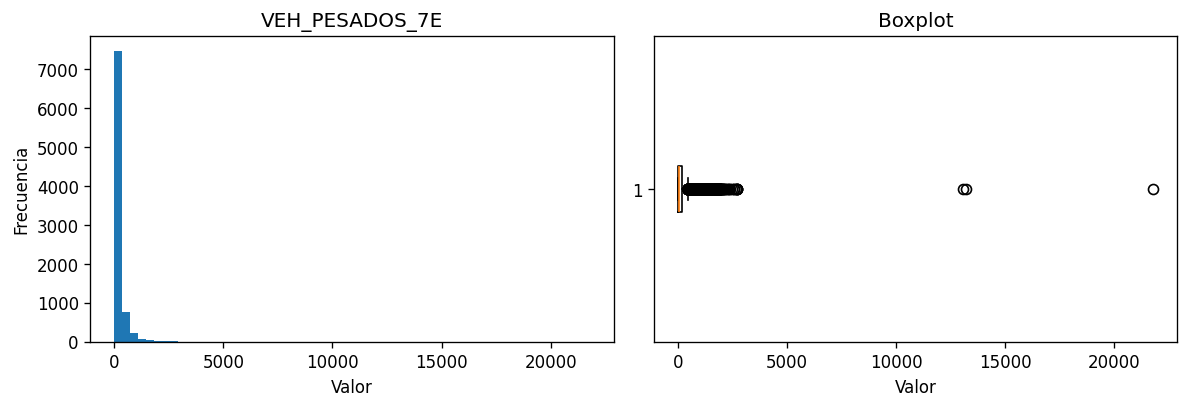

In [3]:
form_global=pd.DataFrame({'skew':df[num_cols].skew(),'exceso_curtosis':df[num_cols].kurt(),
                         'media':df[num_cols].mean(),'mediana':df[num_cols].median(),'max':df[num_cols].max()})
form=pd.DataFrame({'skew':train[num_cols].skew(),'exceso_curtosis':train[num_cols].kurt(),
                  'media':train[num_cols].mean(),'mediana':train[num_cols].median(),'max':train[num_cols].max()})
form['max_sobre_mediana']=form['max']/form['mediana'].replace(0,np.nan)
ordered=form['skew'].abs().sort_values(ascending=False).index.tolist()
top3=ordered[:3];selected=top3[0]
print('GLOBAL');display(form_global.sort_values('skew',ascending=False))
print('TRAIN');display(form.loc[ordered])
print('Tres razones máximo/mediana:');display(form.loc[top3,['max','mediana','max_sobre_mediana']])
print('Columnas |skew|>1 (global/train):',int(form_global['skew'].abs().gt(1).sum()),int(form['skew'].abs().gt(1).sum()))
print('Más sesgada en train:',selected)
x=train[selected].dropna()
fig,axs=plt.subplots(1,2,figsize=(10,3.5))
axs[0].hist(x,bins=60);axs[0].set(title=selected,xlabel='Valor',ylabel='Frecuencia')
axs[1].boxplot(x,vert=False);axs[1].set(title='Boxplot',xlabel='Valor')
plt.tight_layout();plt.show()


## Clase 1 · 3. log1p e inversa
log1p(x)=ln(1+x) está definido en reales para **x > −1**. Por tanto, admite negativos entre −1 y 0. En −1 devuelve −∞; por debajo de −1 produce NaN con NumPy real. No es correcto afirmar que falla para todo negativo.

Se verifica la inversa numéricamente con `allclose`; no se promete igualdad bit a bit. Reducir |skew| no demuestra normalidad ni mejora predictiva. Si el objetivo se transformase, invertir una predicción media en log no recupera automáticamente la media en escala original.


Skew original/log1p: 25.054402043808356 -0.31819251267548104 Inversa: True


,x,log1p
0,-2.0,NaN
1,-1.0,-inf
2,-0.5,-0.693147
3,0.0,0.000000
4,1.0,0.693147


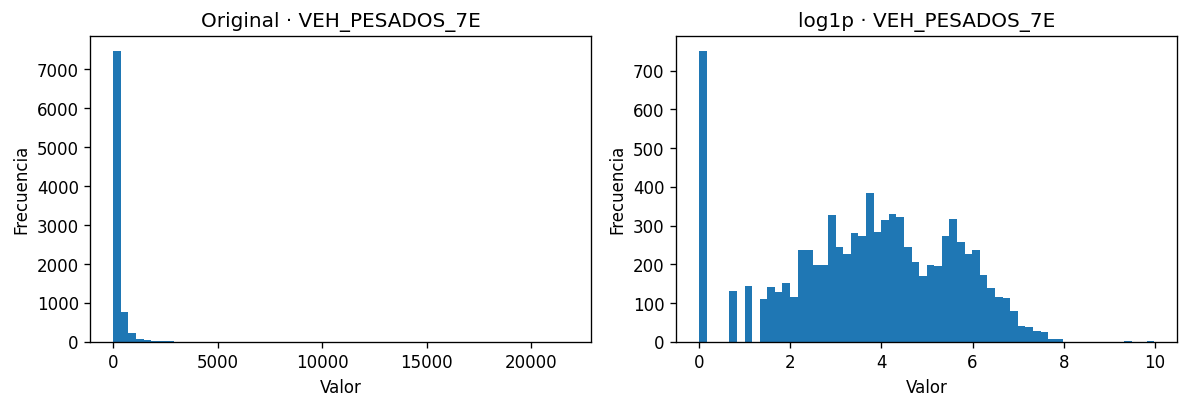

In [4]:
assert (x>=0).all(), 'La selección actual requiere conteos/cargos no negativos.'
logx=np.log1p(x)
inverse_ok=bool(np.allclose(np.expm1(logx),x))
print('Skew original/log1p:',x.skew(),logx.skew(),'Inversa:',inverse_ok)
with np.errstate(divide='ignore',invalid='ignore'):
    display(pd.DataFrame({'x':[-2.,-1.,-.5,0.,1.], 'log1p':np.log1p([-2.,-1.,-.5,0.,1.])}))
fig,axs=plt.subplots(1,2,figsize=(10,3.5))
axs[0].hist(x,bins=60);axs[0].set_title('Original · '+selected)
axs[1].hist(logx,bins=60);axs[1].set_title('log1p · '+selected)
for ax in axs:ax.set(xlabel='Valor',ylabel='Frecuencia')
plt.tight_layout();plt.show()


## Clase 1 · 4. Yeo-Johnson y Box-Cox
El lambda se estima con train observado y se aplica sin reajuste a test observado. Se compara log1p e Yeo-Johnson sobre exactamente las mismas filas de train. Se desactiva `standardize` para separar transformación de forma y escalado posterior.

Box-Cox exige x>0. Si la columna elegida no contiene ceros, la prueba de dominio usa el vector explícito [0,1,2]: es una demostración matemática, no una alteración del dataset. Yeo-Johnson se ajusta por un criterio de verosimilitud bajo normalidad; no minimiza directamente |skew| ni garantiza normalidad.


In [5]:
power=PowerTransformer(method='yeo-johnson',standardize=False)
tr_yj=power.fit_transform(train[[selected]].dropna())
te_yj=power.transform(test[[selected]].dropna())
shape_comparison=pd.DataFrame({'metodo':['Original','log1p','Yeo-Johnson'],
 'skew_train':[x.skew(),logx.skew(),pd.Series(tr_yj.ravel()).skew()]})
shape_comparison['abs_skew']=shape_comparison['skew_train'].abs()
display(shape_comparison)
print('Lambda:',power.lambdas_[0],'Más simétrica de las dos transformaciones:',shape_comparison.iloc[1:].sort_values('abs_skew').iloc[0]['metodo'])
try:
    PowerTransformer(method='box-cox').fit(np.array([[0.],[1.],[2.]]))
except ValueError as err:
    print('Error reproducido con cero:',str(err))
if (x>0).all():
    bc=PowerTransformer(method='box-cox',standardize=False).fit(x.to_numpy().reshape(-1,1))
    print('Box-Cox en esta columna positiva sí funciona; lambda:',bc.lambdas_[0])


,metodo,skew_train,abs_skew
0,Original,25.054402,25.054402
1,log1p,-0.318193,0.318193
2,Yeo-Johnson,-0.030362,0.030362


Lambda: 0.07487431768264238 Más simétrica de las dos transformaciones: Yeo-Johnson
Error reproducido con cero: The Box-Cox transformation can only be applied to strictly positive data


## Clase 1 · 5. Standard, Robust y MinMax
Los tres se ajustan en train. Se informan centros y escalas de la columna seleccionada. Standard usa desviación poblacional (ddof=0); pandas `std()` usa ddof=1 por defecto. La razón desviación/IQR compara dos medidas distintas: **no cuantifica por sí sola cuánto infló un outlier a la desviación**.

MinMax puede producir valores de test fuera de [0,1] si exceden el rango de train. Robust no elimina outliers. Para una base de distancias con extremos conservados se usa Robust en el detector; después de Yeo-Johnson se usa Standard como ejercicio.


In [6]:
std=StandardScaler().fit(x.to_numpy().reshape(-1,1))
rob=RobustScaler().fit(x.to_numpy().reshape(-1,1))
mm=MinMaxScaler().fit(x.to_numpy().reshape(-1,1))
scale_table=pd.DataFrame({'metodo':['Standard','Robust','MinMax'],
 'centro_o_min':[std.mean_[0],rob.center_[0],mm.data_min_[0]],
 'escala_o_rango':[std.scale_[0],rob.scale_[0],mm.data_range_[0]]})
display(scale_table)
print('Desviación/IQR:',std.scale_[0]/rob.scale_[0])
print('Rango MinMax test:',mm.transform(test[[selected]].dropna()).min(),mm.transform(test[[selected]].dropna()).max())


,metodo,centro_o_min,escala_o_rango
0,Standard,163.156051,412.504722
1,Robust,46.000000,179.500000
2,MinMax,0.000000,21799.000000


Desviación/IQR: 2.298076446906562
Rango MinMax test: 0.0 0.14037341162438643


## Clase 1 · 6. Reto: imputación, forma y escala
El pipeline transforma las numéricas; categorías van por imputación y One-Hot. El objetivo y los identificadores no entran. PowerTransformer usa `standardize=False`: de lo contrario el StandardScaler final sería redundante. Se verifica la salida por columna, sin exigir que todas mejoren: una masa grande de ceros puede persistir tras una transformación monótona.

Para un árbol supervisado generalmente se omitirían PowerTransformer y escalado de predictores. El tratamiento de faltantes/categorías depende del estimador utilizado. No se transforman objetivos en este ejercicio.


In [7]:
pipe_num=Pipeline([('imp',SimpleImputer(strategy='median')),
                   ('power',PowerTransformer(method='yeo-johnson',standardize=False)),
                   ('scale',StandardScaler())])
pipe_cat=Pipeline([('imp',SimpleImputer(strategy='most_frequent')),
                  ('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
pre=ColumnTransformer([('num',pipe_num,num_cols),('cat',pipe_cat,cat_cols)],remainder='drop')
prepared_train=pre.fit_transform(train)
prepared_test=pre.transform(test)
num_prepared=pd.DataFrame(prepared_train[:,:len(num_cols)],columns=num_cols,index=train.index)
# Compara sobre la misma población imputada, para no atribuir a YJ el efecto de la imputación.
num_imputed=pd.DataFrame(pre.named_transformers_['num'].named_steps['imp'].transform(train[num_cols]),columns=num_cols,index=train.index)
pipeline_shape=pd.DataFrame({'skew_antes_imputado':num_imputed.skew(),'skew_despues':num_prepared.skew()})
pipeline_shape['mejora_abs']=pipeline_shape['skew_despues'].abs()<pipeline_shape['skew_antes_imputado'].abs()
display(pipeline_shape)
print('Shapes:',prepared_train.shape,prepared_test.shape)
assert np.isfinite(prepared_train).all() and np.isfinite(prepared_test).all()
assert prepared_train.shape[1]==prepared_test.shape[1]
joblib.dump(pre,ROOT/f'models/preprocesador_semana2_{DATASET}.joblib')


,skew_antes_imputado,skew_despues,mejora_abs
VEH_LIGEROS_TAR_DIF,5.989153,0.800869,True
VEH_LIGEROS_AUTOMOVILES,4.140984,-0.025901,True
VEH_PESADOS_TAR_DIF,4.752868,1.285925,True
VEH_PESADOS__2E,2.370858,-0.051235,True
VEH_PESADOS_3E,1.865629,-0.087482,True
VEH_PESADOS_4E,1.972945,-0.083214,True
VEH_PESADOS_5E,2.296283,-0.096378,True
VEH_PESADOS_6E,2.066281,-0.126648,True
VEH_PESADOS_7E,25.060389,-0.030295,True
VEH_LIGEROS_TOTAL,4.059180,0.024727,True


Shapes: (8624, 201) (2157, 201)


## Clase 2 · 0–2. IQR en las tres columnas más sesgadas
Las vallas se aprenden en train observado. Se presentan conteos para k=1,5 y k=3,0 en train/test. Los porcentajes usan como denominador las filas observadas de cada columna, no todo el dataset. Los nulos no se clasifican como normales: se mantienen sin evaluar.

Los cuartiles son robustos, no inmunes. IQR=0 hace que cualquier valor distinto al cuartil se marque; en variables con masa en cero puede ser inadecuado interpretar esto como error. Los bigotes de un boxplot llegan a la observación extrema dentro de las vallas, no necesariamente a las vallas mismas. Un símbolo puede superponerse con otros; la cantidad de puntos dibujados se comprueba con sus datos.


,variable,k,split,IQR_train,bajo,alto,evaluados,outliers,pct
0,VEH_PESADOS_7E,1.5,train,179.5,-257.25,460.75,8619,811,9.409444
1,VEH_PESADOS_7E,1.5,test,179.5,-257.25,460.75,2154,201,9.331476
2,VEH_PESADOS_7E,3.0,train,179.5,-526.50,730.00,8619,376,4.362455
3,VEH_PESADOS_7E,3.0,test,179.5,-526.50,730.00,2154,94,4.363974
4,VEH_LIGEROS_TAR_DIF,1.5,train,396.0,-594.00,990.00,8624,1805,20.929963
5,VEH_LIGEROS_TAR_DIF,1.5,test,396.0,-594.00,990.00,2157,440,20.398702
6,VEH_LIGEROS_TAR_DIF,3.0,train,396.0,-1188.00,1584.00,8624,1691,19.608071
7,VEH_LIGEROS_TAR_DIF,3.0,test,396.0,-1188.00,1584.00,2157,412,19.100603
8,VEH_PESADOS_TAR_DIF,1.5,train,0.0,0.00,0.00,8624,2029,23.527365
9,VEH_PESADOS_TAR_DIF,1.5,test,0.0,0.00,0.00,2157,487,22.577654


Puntos en datos del boxplot / IQR: 811 811


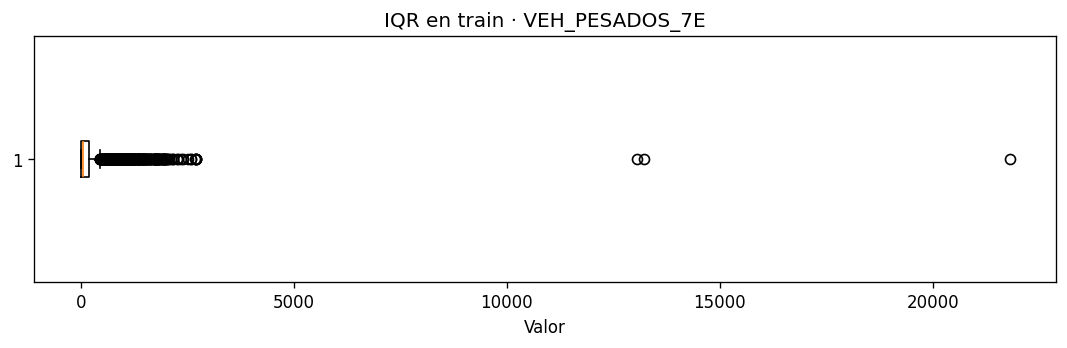

In [8]:
def iqr_limits(s,k=1.5):
    q1,q3=s.dropna().quantile([.25,.75]); spread=q3-q1
    return float(q1-k*spread),float(q3+k*spread),float(spread)
def flags_iqr(s,lo,hi):
    out=pd.Series(pd.NA,index=s.index,dtype='Int64')
    observed=s.notna();out.loc[observed]=(s.loc[observed].lt(lo)|s.loc[observed].gt(hi)).astype(int)
    return out
rows=[]
for c in top3:
    for k in [1.5,3.]:
        lo,hi,spread=iqr_limits(train[c],k)
        for split,frame in [('train',train),('test',test)]:
            flags=flags_iqr(frame[c],lo,hi)
            rows.append({'variable':c,'k':k,'split':split,'IQR_train':spread,'bajo':lo,'alto':hi,
                         'evaluados':int(flags.notna().sum()),'outliers':int(flags.sum()),'pct':float(flags.mean()*100)})
iqr_table=pd.DataFrame(rows);display(iqr_table)
fig,ax=plt.subplots(figsize=(9,3))
bp=ax.boxplot(train[selected].dropna(),vert=False,whis=1.5)
lo,hi,_=iqr_limits(train[selected]);expected=int(flags_iqr(train[selected],lo,hi).sum())
plotted=len(bp['fliers'][0].get_xdata())
print('Puntos en datos del boxplot / IQR:',plotted,expected);assert plotted==expected
ax.set(title='IQR en train · '+selected,xlabel='Valor');plt.tight_layout();plt.show()


## Clase 2 · 3. Z-score e IQR: comprobar la afirmación del HTML
Se trabaja con una columna sesgada fijada (`VEH_TOTAL` en peajes, `Total Charges` en Telco). Media y desviación se estiman en train observado; se aplica el mismo umbral a test. Log cambia la geometría y puede destacar valores muy pequeños. **No hay garantía de que su conteo se acerque al de IQR**.

El Z-score se puede calcular sin normalidad; lo que requiere cuidado es interpretar |z|>3 como una cola excepcional bajo un modelo normal. Sin etiquetas verdaderas de anomalía, «marca menos» no equivale a «subcuenta errores» ni más detecciones equivale a más precisión.


In [9]:
s=train[focus].dropna();lo,hi,_=iqr_limits(s)
mu,sd=s.mean(),s.std(ddof=1)
logs=np.log1p(s);mul,sdl=logs.mean(),logs.std(ddof=1)
zrows=[]
for split,frame in [('train',train),('test',test)]:
    v=frame[focus].dropna()
    counts={'IQR':int(((v<lo)|(v>hi)).sum()),
            'Z crudo':int((((v-mu)/sd).abs()>3).sum()),
            'Z log1p':int((((np.log1p(v)-mul)/sdl).abs()>3).sum())}
    for method,count in counts.items():zrows.append({'split':split,'metodo':method,'n':count,'evaluados':len(v)})
z_table=pd.DataFrame(zrows);display(z_table)
count_tr=z_table.query("split=='train'").set_index('metodo')['n']
print('Distancia al conteo IQR, antes/después:',abs(count_tr['IQR']-count_tr['Z crudo']),abs(count_tr['IQR']-count_tr['Z log1p']))
print('Una diferencia de conteos no mide exactitud; no se fuerza la conclusión del ejemplo.')


,split,metodo,n,evaluados
0,train,IQR,700,8030
1,train,Z crudo,143,8030
2,train,Z log1p,26,8030
3,test,IQR,183,2010
4,test,Z crudo,41,2010
5,test,Z log1p,12,2010


Distancia al conteo IQR, antes/después: 557 674
Una diferencia de conteos no mide exactitud; no se fuerza la conclusión del ejemplo.


## Clase 2 · 4. Isolation Forest
Se emplean conteos de categorías, sin incluir a la vez su total determinista. Se conservan solo casos completos para este detector y se informa cuántos quedaron sin evaluar; no se borran del dataframe original. Es el enfoque didáctico del HTML, con el mismo split de base.

RobustScaler se ajusta con train. El escalado es relevante para LOF; **Isolation Forest estándar no lo requiere por distancias**, y los cambios afines positivos suelen preservar sus particiones aleatorias salvo efectos numéricos. Sí puede cambiar al aplicar transformaciones no lineales. Contamination ajusta el umbral; no descubre la prevalencia verdadera.


In [10]:
A=train[mult_cols].dropna();B=test[mult_cols].dropna()
sc=RobustScaler().fit(A);Atr=sc.transform(A);Bte=sc.transform(B)
print('Features:',mult_cols,'Casos completos train/test:',A.shape,B.shape)
print('Sin evaluar train/test:',len(train)-len(A),len(test)-len(B))
iso_rows=[];isos={}
for contamination in [.01,.05,.10]:
    model=IsolationForest(contamination=contamination,random_state=42,n_estimators=100)
    model.fit(Atr);isos[contamination]=model
    iso_rows.append({'contamination':contamination,'anom_train':int((model.predict(Atr)==-1).sum()),
                    'n_train':len(A),'anom_test':int((model.predict(Bte)==-1).sum()),'n_test':len(B)})
iso_table=pd.DataFrame(iso_rows);display(iso_table)
iso=isos[.05];iso_tr=iso.predict(Atr);iso_te=iso.predict(Bte)
# Más anómalos según score menor; muestra de tres casos en test.
rank=pd.Series(iso.decision_function(Bte),index=B.index).sort_values()
flagged=rank.loc[rank<0].index[:3]
inspection=df.loc[flagged,context+mult_cols].copy()
inspection['score_iso']=rank.loc[flagged]
display(inspection)


Features: ['VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E'] Casos completos train/test: (8616, 6) (2152, 6)
Sin evaluar train/test: 8 5


,contamination,anom_train,n_train,anom_test,n_test
0,0.01,87,8616,23,2152
1,0.05,431,8616,114,2152
2,0.10,862,8616,229,2152


,ID,NOMBRE_PEAJE,ANIO,MES,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,score_iso
10496,10496,Chilca,2025,3,607284.0,72794.0,42976.0,10798.0,18588.0,88756.0,-0.156863
10549,10549,Chilca,2025,4,556894.0,70430.0,42698.0,10540.0,18072.0,86222.0,-0.152742
7332,7332,Chilca,2021,12,668230.0,59442.0,38642.0,10140.0,18810.0,83396.0,-0.144461


## Clase 2 · 5. LOF: vecindarios 10, 20 y 35
LOF se ajusta y evalúa en train con `fit_predict`; no se aplica este modo a test. Se usa contamination='auto' para reproducir la lógica por defecto. Cambiar k modifica la referencia local; no garantiza un conteo monótono. Se informa intersección y unión con Isolation Forest de 5 % sobre **las mismas filas de entrenamiento**.

Un caso señalado solo por LOF puede ser raro respecto de sus vecinos y no quedar aislado globalmente. Coincidencia no implica que sea un error. En despliegue, LOF con novelty=True se evalúa sobre observaciones nuevas; no se debe confundir ese uso con fit_predict.


Filas adicionales con mismo perfil numérico: 636
Mayor multiplicidad de un perfil: 586


,k,lof_train,iso_train,ambos,union,jaccard
0,10,384,431,12,803,0.014944
1,20,310,431,13,728,0.017857
2,35,216,431,22,625,0.035200


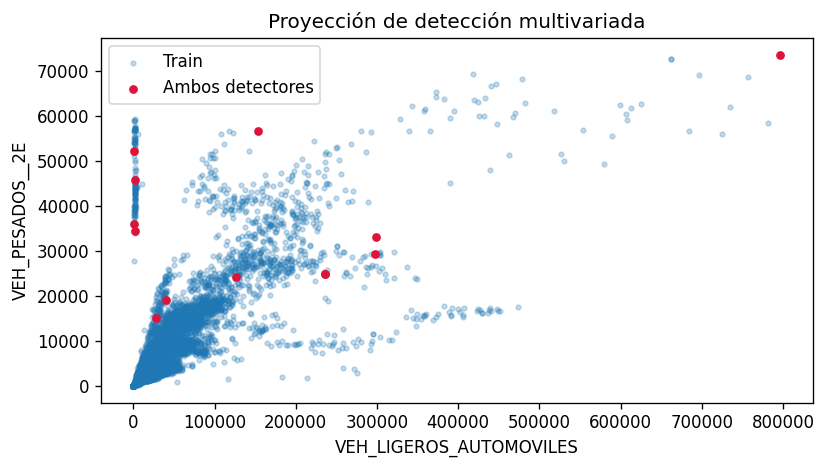

Advertencia registrada: k=10: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
Advertencia registrada: k=20: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
Advertencia registrada: k=35: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.


In [11]:
import warnings
lof_rows=[];lof_preds={};lof_warnings=[]
print('Filas adicionales con mismo perfil numérico:',int(A.duplicated().sum()))
print('Mayor multiplicidad de un perfil:',int(A.value_counts().max()))
for k in [10,20,35]:
    with warnings.catch_warnings(record=True) as ws:
        warnings.simplefilter('always')
        pred=LocalOutlierFactor(n_neighbors=k,contamination='auto').fit_predict(Atr)
    lof_warnings.extend([f'k={k}: {w.message}' for w in ws])
    lof_preds[k]=pred
    both=int(((pred==-1)&(iso_tr==-1)).sum())
    union=int(((pred==-1)|(iso_tr==-1)).sum())
    lof_rows.append({'k':k,'lof_train':int((pred==-1).sum()),'iso_train':int((iso_tr==-1).sum()),
                     'ambos':both,'union':union,'jaccard':both/union if union else np.nan})
lof_table=pd.DataFrame(lof_rows);display(lof_table)
fig,ax=plt.subplots(figsize=(7,4))
ax.scatter(A.iloc[:,0],A.iloc[:,1],s=8,alpha=.25,label='Train')
both_mask=(lof_preds[20]==-1)&(iso_tr==-1)
ax.scatter(A.loc[both_mask].iloc[:,0],A.loc[both_mask].iloc[:,1],s=18,color='crimson',label='Ambos detectores')
ax.set(xlabel=mult_cols[0],ylabel=mult_cols[1],title='Proyección de detección multivariada')
ax.legend();plt.tight_layout();plt.show()

for message in lof_warnings: print('Advertencia registrada:',message)


### Integración y sensibilidad de los detectores
El ejemplo del HTML aplica RobustScaler a conteos crudos. Esa es la base de los conteos anteriores, para conservar unidades interpretables. Como integración de la Clase 1, se compara también Isolation Forest sobre las mismas seis/tres columnas después de Yeo-Johnson y escalado: la transformación no lineal puede cambiar los cortes y las detecciones. No se elige una variante por producir más anomalías.

Los perfiles repetidos pueden hacer inestable la densidad local de LOF. En peajes se repite el análisis, como sensibilidad, excluyendo del subconjunto de ajuste los totales cero sospechosos. Se reajustan escala, Isolation Forest y LOF en ese subconjunto. No se elimina ninguna fila del dataframe original ni se afirma que las filas excluidas sean errores.


In [12]:
shape_detector=Pipeline([('power',PowerTransformer(method='yeo-johnson',standardize=False)),('scale',StandardScaler())])
shape_A=shape_detector.fit_transform(A);shape_B=shape_detector.transform(B)
iso_shape=IsolationForest(contamination=.05,random_state=42,n_estimators=100).fit(shape_A)
transformed_comparison={'raw_train':int((iso_tr==-1).sum()),'raw_test':int((iso_te==-1).sum()),
 'yj_train':int((iso_shape.predict(shape_A)==-1).sum()),'yj_test':int((iso_shape.predict(shape_B)==-1).sum()),
 'ambos_test':int(((iso_te==-1)&(iso_shape.predict(shape_B)==-1)).sum())}
print('Isolation Forest con forma transformada:',transformed_comparison)
sensitivity=[]
if DATASET=='peajes':
    S=A.loc[train.loc[A.index,'sin_reporte'].eq(0)]
    ssc=RobustScaler().fit(S);SV=ssc.transform(S)
    si=IsolationForest(contamination=.05,random_state=42,n_estimators=100).fit(SV)
    isp=si.predict(SV)
    print('Sensibilidad sin totales cero: filas',len(S),'perfiles adicionales repetidos',int(S.duplicated().sum()))
    for k in [10,20,35]:
        with warnings.catch_warnings(record=True) as ws:
            warnings.simplefilter('always')
            lp=LocalOutlierFactor(n_neighbors=k).fit_predict(SV)
        sensitivity.append({'k':k,'n':len(S),'lof':int((lp==-1).sum()),'iso':int((isp==-1).sum()),
         'ambos':int(((lp==-1)&(isp==-1)).sum()),'advertencias':'; '.join(str(w.message) for w in ws)})
    display(pd.DataFrame(sensitivity))


Isolation Forest con forma transformada: {'raw_train': 431, 'raw_test': 114, 'yj_train': 431, 'yj_test': 111, 'ambos_test': 86}
Sensibilidad sin totales cero: filas 8030 perfiles adicionales repetidos 51


,k,n,lof,iso,ambos,advertencias
0,10,8030,368,402,11,
1,20,8030,285,402,13,
2,35,8030,182,402,12,


## Clase 2 · 6. Investigar y tratar sin perder el original
Se inspeccionan las cinco observaciones más altas y el contexto de los casos marcados. Valores altos por sí solos no prueban error ni legitimidad. Se mantiene la clasificación provisional hasta contrastar la fuente.

El tratamiento elegido es **marcar para revisión y conservar**. Se ilustra además una columna capada al p99 de train, conservando la original. Winsorizar modifica información de magnitud, aunque conserve filas: no se adopta automáticamente. Nunca se recorta un objetivo de prueba para mejorar artificialmente una métrica.

Los registros incompletos conservan `NA` en la bandera de Isolation Forest para distinguir «sin evaluar» de «normal». La bandera no debe convertirse en etiqueta de fraude sin validación.


In [13]:
top_values=df.nlargest(5,focus)[context+[focus]]
display(top_values)
trace=df.copy()
trace['es_outlier_iso']=pd.Series(pd.NA,index=df.index,dtype='Int64')
trace.loc[A.index,'es_outlier_iso']=(iso_tr==-1).astype(int)
trace.loc[B.index,'es_outlier_iso']=(iso_te==-1).astype(int)
trace['es_outlier_iqr']=flags_iqr(df[focus],lo,hi)
p99=float(train[focus].quantile(.99))
trace[focus+'_cap_p99']=df[focus].clip(upper=p99)
cap_counts={'train':int(train[focus].gt(p99).sum()),'test':int(test[focus].gt(p99).sum())}
print('p99 aprendido en train:',p99,'Valores capados:',cap_counts)
display(trace['es_outlier_iso'].value_counts(dropna=False).to_frame('n'))
assert trace[focus].equals(df[focus]), 'El original debe conservarse.'
# Trazabilidad guardada sin publicar el dataset completo.
trace.loc[flagged,context+mult_cols+['es_outlier_iso','es_outlier_iqr']].to_json(
    ROOT/f'reports/casos_{DATASET}.json',orient='records',indent=2,force_ascii=False)
joblib.dump({'scaler':sc,'detector':iso,'features':mult_cols,'p99':p99,'iqr':[lo,hi]},ROOT/f'models/detector_{DATASET}.joblib')


,ID,NOMBRE_PEAJE,ANIO,MES,VEH_TOTAL
10345,10345,Chilca,2025,1,1037544.0
7494,7494,Chilca,2022,2,980656.0
9357,9357,Chilca,2024,1,968718.0
9438,9438,Chilca,2024,2,962816.0
8466,8466,Chilca,2023,2,935340.0


p99 aprendido en train: 429720.11000000004 Valores capados: {'train': 81, 'test': 27}


,n
es_outlier_iso,
0,10223
1,545
<NA>,13


In [14]:
# Investigar los máximos de 7 ejes en su serie local, sin inferir automáticamente error.
rare=raw.nlargest(3,'VEH_PESADOS_7E')
for idx,row in rare.iterrows():
    period=int(row.ANIO)*12+int(row.MES)
    delta=raw.ANIO*12+raw.MES-period
    view=raw.loc[raw.CODIGO_PEAJE.eq(row.CODIGO_PEAJE)&delta.between(-2,2),
                 ['NOMBRE_PEAJE','ANIO','MES','VEH_PESADOS_7E','VEH_PESADOS_TOTAL']].sort_values(['ANIO','MES'])
    display(view)


,NOMBRE_PEAJE,ANIO,MES,VEH_PESADOS_7E,VEH_PESADOS_TOTAL
5030,Corcona-Concesión,2019,7,538.0,107907
5107,Corcona-Concesión,2019,8,612.0,112778
5184,Corcona-Concesión,2019,9,21799.0,169380
5261,Corcona-Concesión,2019,10,556.0,110357
5338,Corcona-Concesión,2019,11,400.0,106479


,NOMBRE_PEAJE,ANIO,MES,VEH_PESADOS_7E,VEH_PESADOS_TOTAL
3480,Socos,2017,10,4.0,15076
3556,Socos,2017,11,6.0,14251
3632,Socos,2017,12,13220.0,87525
3709,Socos,2018,1,0.0,14077
3786,Socos,2018,2,4.0,13910


,NOMBRE_PEAJE,ANIO,MES,VEH_PESADOS_7E,VEH_PESADOS_TOTAL
5491,Ccasacancha (Huillque),2020,1,81.0,17498
5570,Ccasacancha (Huillque),2020,2,27.0,16265
5649,Ccasacancha (Huillque),2020,3,13064.0,25249
5728,Ccasacancha (Huillque),2020,4,3.0,5281
5807,Ccasacancha (Huillque),2020,5,17.0,9049


**Interpretación de origen:** los cinco mayores totales corresponden al mismo peaje, Chilca, en meses de 2022–2025. La recurrencia respalda tratarlos como candidatos a extremos de alto flujo, no como errores demostrados. En cambio, los picos de siete ejes de Corcona-Concesión, Socos y Ccasacancha se deben contrastar con meses vecinos y el registro de origen: pueden ser cambios reales, clasificación de ejes o errores. Se clasifican como anomalías de revisión, conservando su valor. Sin metadatos de operación no se puede certificar la causa.


## Clase 2 · 7. Conclusión del reto
Para una primera herramienta de revisión usaría Isolation Forest como ranking multivariado, junto con verificaciones explícitas de dominio y contexto. LOF aporta contraste local sobre train. Mantendría los registros y una bandera, revisando muestras con expertos antes de fijar un umbral operativo. No elegiría contamination por el número que parezca más cómodo ni afirmaría exactitud sin etiquetas verificadas.

En peajes, la heterogeneidad entre estaciones y la estacionalidad requieren comparar también con el mismo peaje y meses anteriores. En Telco, la finalidad predictiva es churn, y la detección de anomalías no sustituye evaluación de clasificación. Las transformaciones y el tratamiento final se decidirían mediante validación del modelo y su objetivo, no por lograr skew cero.

Todos los conteos de esta entrega son calculados. Cuando una premisa del HTML no se cumple (por ejemplo, que Z log converja al conteo de IQR), se responde con la evidencia en vez de modificar el experimento para forzarla.


In [15]:
summary={'dataset':DATASET,'source_sha256':hashlib.sha256(path.read_bytes()).hexdigest(),
 'rows':len(raw),'cols':len(raw.columns),'train_rows':len(train),'test_rows':len(test),
 'numeric_cols':num_cols,'top3_train':top3,'selected':selected,
 'strong_skew_global':int(form_global['skew'].abs().gt(1).sum()),
 'strong_skew_train':int(form['skew'].abs().gt(1).sum()),
 'lambda':float(power.lambdas_[0]),'inverse_ok':inverse_ok,
 'form_global':form_global.reset_index(names='variable').to_dict('records'),
 'form_train':form.reset_index(names='variable').to_dict('records'),
 'shape_comparison':shape_comparison.to_dict('records'),
 'pipeline_shape':pipeline_shape.reset_index(names='variable').to_dict('records'),
 'pipeline_train_shape':list(prepared_train.shape),'pipeline_test_shape':list(prepared_test.shape),
 'scalers':scale_table.to_dict('records'),'iqr':iqr_table.to_dict('records'),'zscore':z_table.to_dict('records'),
 'isolation':iso_table.to_dict('records'),'lof':lof_table.to_dict('records'),
 'p99':p99,'cap_counts':cap_counts,'top_values':top_values.to_dict('records'),
 'three_anomalies':inspection.to_dict('records')}
if DATASET=='peajes':summary['zero_total']=raw_zero_count
else:summary['total_charges_missing']=int(df['Total Charges'].isna().sum())
summary['lof_warnings']=lof_warnings
summary['lof_sensitivity']=sensitivity
summary['iso_transformed']=transformed_comparison
if DATASET=='telco':summary['imputation']=imputation_scores.to_dict('records')
# pandas serializa los NaN como null, sin emitir JSON no estándar.
pd.Series(summary).to_json(ROOT/f'reports/resultados_{DATASET}.json',force_ascii=False,indent=2)
print('Resultados y modelos guardados. No se borraron filas del dataframe original.')


Resultados y modelos guardados. No se borraron filas del dataframe original.
